# Graph 4: Movie Runtime by Genre Over Time

In [ ]:
# !pip install matplotlib seaborn pandas

/var/folders/xm/0cp026fs5hx017j8zxljvf6m0000gn/T/ipykernel_50930/1889117521.py:40: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df[(df["type"]=="Movie") & df["duration_value"].notna()]


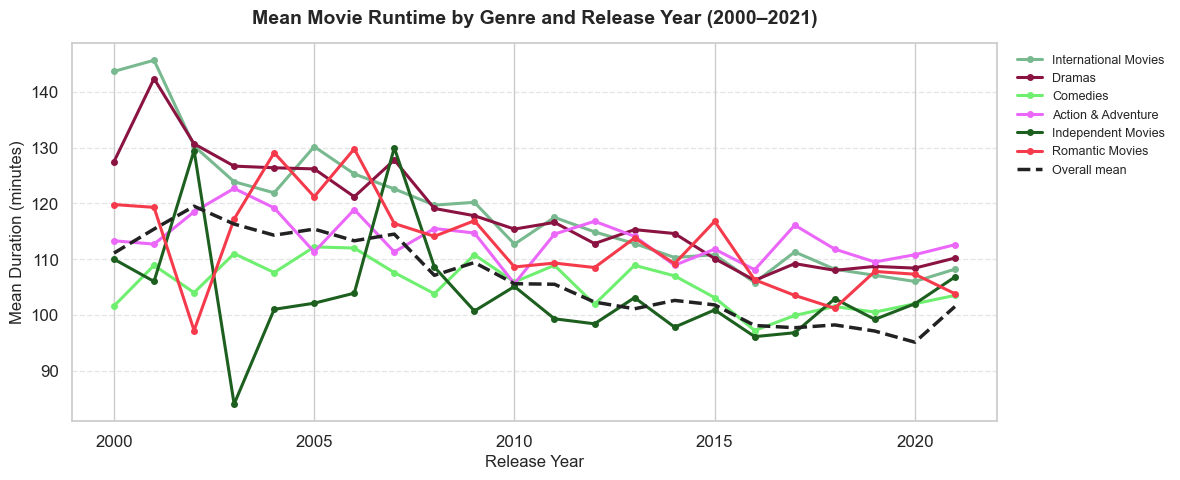

Saved -> graph4_movie_runtime.png


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from genre_colors import GENRE_COLORS

df = pd.read_csv("netflix_titles_clean.csv")
df["genre"] = df["listed_in"].str.split(", ")
exploded = df.explode("genre")
exploded["genre"] = exploded["genre"].str.strip()

# Top 6 movie genres dynamically
top_genres = (
    exploded[exploded["type"]=="Movie"]["genre"]
    .value_counts().head(6).index.tolist()
)

year_min = 2000
year_max = int(df["release_year"].max())

movies = df[(df["type"]=="Movie") & df["duration_value"].notna()]
movies = movies.copy()
movies["genre"] = movies["listed_in"].str.split(", ")
movies = movies.explode("genre")
movies["genre"] = movies["genre"].str.strip()

data = (
    movies[
        movies["genre"].isin(top_genres) &
        movies["release_year"].between(year_min, year_max)
    ]
    .groupby(["release_year","genre"])["duration_value"]
    .mean().round(1)
    .reset_index()
)
data.columns = ["year","genre","mean_runtime"]

# Overall mean across all movies (no genre filter)
overall = (
    df[(df["type"]=="Movie") & df["duration_value"].notna()]
    [df["release_year"].between(year_min, year_max)]
    .groupby("release_year")["duration_value"]
    .mean().round(1).reset_index()
)
overall.columns = ["year", "mean_runtime"]

sns.set_theme(style="whitegrid", font_scale=1.1)
fig, ax = plt.subplots(figsize=(12, 5))

for genre in top_genres:
    subset = data[data["genre"]==genre].sort_values("year")
    ax.plot(
        subset["year"], subset["mean_runtime"],
        marker="o", linewidth=2.2, markersize=4,
        color=GENRE_COLORS.get(genre, "#888888"), label=genre,
    )

# Overall mean — thick black dashed line
ax.plot(
    overall["year"], overall["mean_runtime"],
    color="#222222", linewidth=2.5, linestyle="--",
    marker=None, label="Overall mean", zorder=10,
)

ax.set_title(
    f"Mean Movie Runtime by Genre and Release Year ({year_min}\u2013{year_max})",
    fontsize=14, fontweight="bold", pad=14
)
ax.set_xlabel("Release Year", fontsize=12)
ax.set_ylabel("Mean Duration (minutes)", fontsize=12)
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig("graph4_movie_runtime.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> graph4_movie_runtime.png")
